In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.patches as patches

from glob import glob
import os
import logging
import datetime
import warnings
import re
import sys 
from skimage import io

from copy import deepcopy

# from matplotlib.colors import Normalize
from scipy.optimize import curve_fit

plt.rcParams['xtick.major.width'] = 1.8
plt.rcParams['axes.edgecolor'] = 'k'
plt.rcParams['errorbar.capsize'] = 5
plt.rcParams['lines.markersize'] = 4.

In [207]:
roi = [1500, 1650, 800, 950]  # [ymin, ymax, xmin, xmax]
roi_bg = [10, 150, 1897, 2037]

In [6]:
def get_power_ramp(path, roi):
    """Plot the power ramp data for the specified path."""
    files = sorted(glob(path+'\*.tif'), reverse=False)
    power_df = pd.read_csv(path + '\power_ramp.csv')
    assert len(power_df) == len(files)
    avg_counts = []
    std_counts = []
    sum_counts = []
    for f in files:
        img0 = io.imread(f).astype(np.int64)
        imroi = img0[roi[0]:roi[1], roi[2]:roi[3]]
        avg_counts.append(imroi.mean())
        sum_counts.append(imroi.sum())
        std_counts.append(imroi.std() / np.sqrt(imroi.size))

    power_df['avg_counts'] = avg_counts
    power_df['std_counts'] = std_counts
    power_df['sum_counts'] = sum_counts
    # power_df['power(uW)'] = sorted(power_df['power(uW)'], reverse=True)
    return power_df    

In [3]:
def get_power(path):
    """Get the exposure time from the settings file.
    Args: path: string with the path to the directory with the settings file.
    Returns: texp: float with the exposure time.
    """
    file_settings = path + '/settings.json'
    df_settings = pd.read_csv(file_settings, sep=':', names=['setting', 'value'], index_col='setting')
    power = float(df_settings.loc['POWER(uW)'].values[0])
    print(f'P = {power} µW')
    return power

# Power ramps with automatic ND filter

In [174]:
path7 = r'G:\My Drive\Ba Tagging\data\img\ramp\03-04-25\Rhodamine-B 50 µM 270225\2-filt7-575nm'
files7 = sorted(glob.glob(path7+'\*.tif'), reverse=False)
power_df7 = pd.read_csv(path7 + '\power_ramp.csv')
## power_df7['power(uW)'] = sorted(power_df7['power(uW)'], reverse=True) 
print(len(power_df7), len(files7))

21 21


In [ ]:
# # for f in files7[1:]:     # Fix the file names
#     fdir_split = os.path.split(f)
#     fdir = fdir_split[0]
#     fname = fdir_split[1]
#     fname_split = fname.split('_P_')
#     powerW = float(fname_split[1][:-6])
#     poweruW = round(powerW*1e6, 2)
#     corrected_fname = fname_split[0] + '_P_' + str(poweruW) + 'uW.tif'
#     os.rename(f, fdir + '\\' + corrected_fname)
# files7 = sorted(glob.glob(path7+'\*.tif'), reverse=False)


In [175]:
files7[-1]

'G:\\My Drive\\Ba Tagging\\data\\img\\ramp\\03-04-25\\Rhodamine-B 50 µM 270225\\2-filt7-575nm\\Center-575nm_Width-35nm_10-18-30_P_871.9uW.tif'

In [176]:
img0.shape[0] - 150

1898

Maximum pixel intensity at Row: 1559 Col: 881


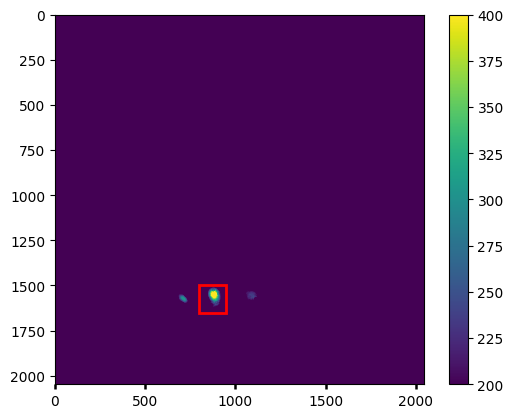

In [202]:
img0 = io.imread(files7[-1]).astype(np.int64)
flat_index = np.argmax(img0)
row, col = np.unravel_index(flat_index, img0.shape)
print('Maximum pixel intensity at Row:', row, 'Col:', col)
roi = [1500, 1650, 800, 950]  # [ymin, ymax, xmin, xmax]
roi_bg = [10, 150, 1897, 2037]
plt.imshow(img0, clim=(200, 400))
imroi = img0[roi[0]:roi[1], roi[2]:roi[3]]
plt.gca().add_patch(patches.Rectangle((roi[2], roi[0]), roi[3]-roi[2], roi[1]-roi[0], fill=False, edgecolor='red', lw=2))
plt.colorbar()

# Rhodamine-B 50 µM 270225

In [189]:
roi = [1500, 1650, 800, 950]

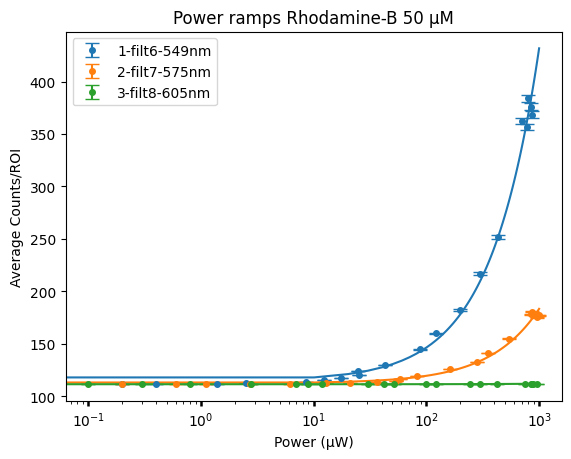

In [222]:
path0 = r'G:\My Drive\Ba Tagging\data\img\ramp\03-04-25\Rhodamine-B 50 µM 270225'
rhb50 = {}
subdirs = sorted(next(os.walk(path0))[1])
for subdir in subdirs:
    path = os.path.join(path0, subdir)
    power_df = get_power_ramp(path, roi=roi)
    rhb50[subdir] = power_df

    linear_fit = np.poly1d(np.polyfit(power_df['power(uW)'], power_df['avg_counts'], 1))
    x_fit = np.linspace(0, 1000, 100)
    
    lines = plt.errorbar(power_df['power(uW)'], power_df['avg_counts'], yerr=power_df['std_counts'], fmt='o', label=subdir)
    plt.plot(x_fit, linear_fit(x_fit), '-', color = lines[0].get_color())

    plt.gca().set(xlabel='Power (µW)', ylabel='Average Counts/ROI', xscale='log', title='Power ramps Rhodamine-B 50 µM')
    plt.legend()

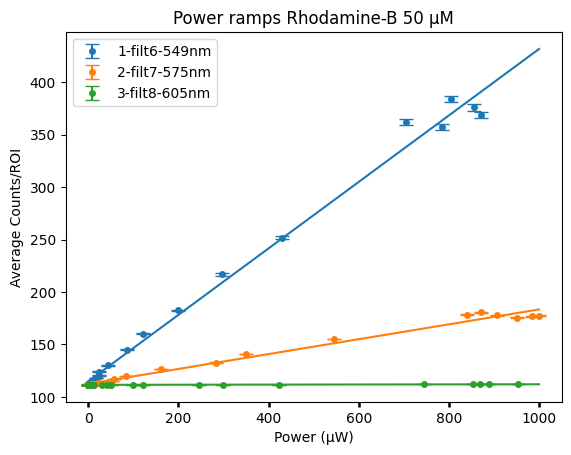

In [216]:
path0 = r'G:\My Drive\Ba Tagging\data\img\ramp\03-04-25\Rhodamine-B 50 µM 270225'

subdirs = sorted(next(os.walk(path0))[1],)
for subdir in subdirs:
    path = os.path.join(path0, subdir)
    power_df = get_power_ramp(path, roi=roi)

    linear_fit = np.poly1d(np.polyfit(power_df['power(uW)'], power_df['avg_counts'], 1))
    x_fit = np.linspace(0, 1000, 100)
    
    lines = plt.errorbar(power_df['power(uW)'], power_df['avg_counts'], yerr=power_df['std_counts'], fmt='o', label=subdir)
    plt.plot(x_fit, linear_fit(x_fit), '-', color = lines[0].get_color())

    plt.gca().set(xlabel='Power (µW)', ylabel='Average Counts/ROI', xscale='linear', title='Power ramps Rhodamine-B 50 µM')#, xlim=(-10, 50), ylim=(100, 130))
    plt.legend()

# Rhodamine-B 5 µM 270225

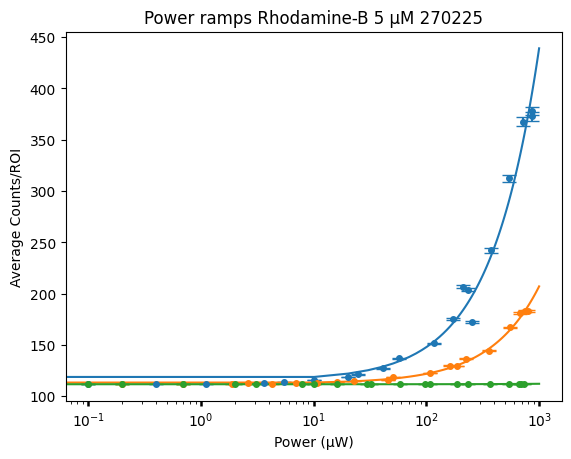

In [220]:
path0 = r'G:\My Drive\Ba Tagging\data\img\ramp\03-04-25\Rhodamine-B 5 µM 270225'

subdirs = sorted(next(os.walk(path0))[1])
rhb5 = {}
for subdir in subdirs:
    path = os.path.join(path0, subdir)
    power_df = get_power_ramp(path, roi=roi)
    rhb5[subdir] = power_df
    linear_fit = np.poly1d(np.polyfit(power_df['power(uW)'], power_df['avg_counts'], 1))
    x_fit = np.linspace(0, 1000, 100)
    
    lines = plt.errorbar(power_df['power(uW)'], power_df['avg_counts'], yerr=power_df['std_counts'], fmt='o', label=subdir)
    plt.plot(x_fit, linear_fit(x_fit), '-', color = lines[0].get_color())

    plt.gca().set(xlabel='Power (µW)', ylabel='Average Counts/ROI', xscale='log', title='Power ramps ' + path0.split('\\')[-1])

# Fused silica ramps

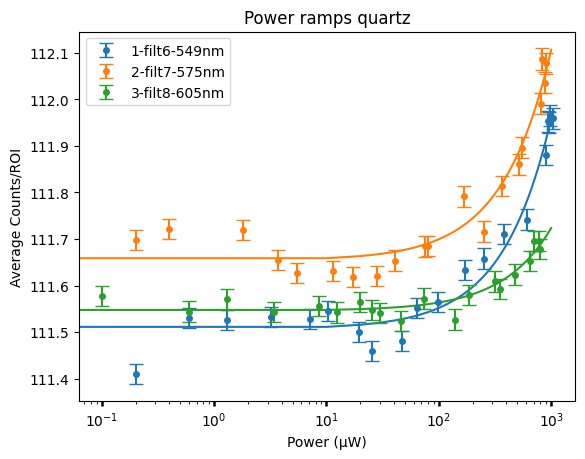

In [218]:
path0 = r'G:\My Drive\Ba Tagging\data\img\ramp\03-04-25\quartz'
fs = {}
subdirs = sorted(next(os.walk(path0))[1])
for subdir in subdirs:
    path = os.path.join(path0, subdir)
    power_df = get_power_ramp(path, roi=roi)
    fs[subdir] = power_df
    linear_fit = np.poly1d(np.polyfit(power_df['power(uW)'], power_df['avg_counts'], 1))
    x_fit = np.linspace(0, 1000, 100)
    
    lines = plt.errorbar(power_df['power(uW)'], power_df['avg_counts'], yerr=power_df['std_counts'], fmt='o', label=subdir)
    plt.plot(x_fit, linear_fit(x_fit), '-', color = lines[0].get_color())

    plt.gca().set(xlabel='Power (µW)', ylabel='Average Counts/ROI', xscale='log', title='Power ramps ' + path0.split('\\')[-1])
    plt.legend()

# Find intrinsic Background: ROI far away from spot

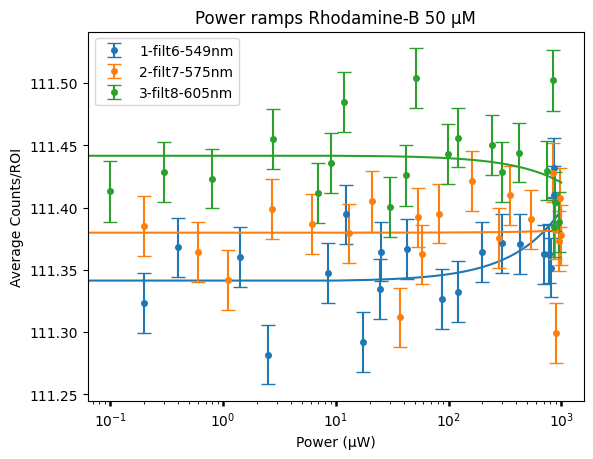

In [224]:
roi_bg = [0, 150, 1897, 2047]

path0 = r'G:\My Drive\Ba Tagging\data\img\ramp\03-04-25\Rhodamine-B 50 µM 270225'
bg50 = {}
subdirs = sorted(next(os.walk(path0))[1])
for subdir in subdirs:
    path = os.path.join(path0, subdir)
    power_df = get_power_ramp(path, roi=roi_bg)
    bg50[subdir] = power_df

    linear_fit = np.poly1d(np.polyfit(power_df['power(uW)'], power_df['avg_counts'], 1))
    x_fit = np.linspace(0, 1000, 100)
    
    lines = plt.errorbar(power_df['power(uW)'], power_df['avg_counts'], yerr=power_df['std_counts'], fmt='o', label=subdir)
    plt.plot(x_fit, linear_fit(x_fit), '-', color = lines[0].get_color())

    plt.gca().set(xlabel='Power (µW)', ylabel='Average Counts/ROI', xscale='log', title='Power ramps Rhodamine-B 50 µM')
    plt.legend()

# Compare all three samples + bg

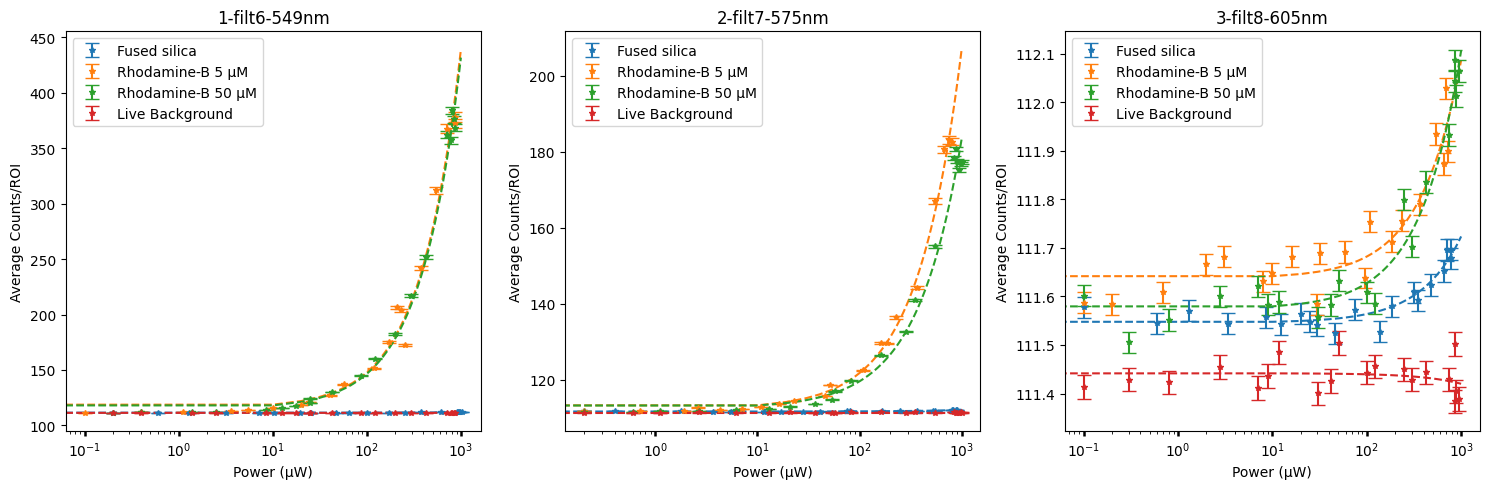

In [225]:
filters = ['1-filt6-549nm', '2-filt7-575nm', '3-filt8-605nm']
sample_names = ['Fused silica', 'Rhodamine-B 5 µM', 'Rhodamine-B 50 µM', 'Live Background']
fig, ax = plt.subplots(1, 3, figsize=(15, 5))
for i, f in enumerate(filters):
    for j, sample in enumerate([fs, rhb5, rhb50, bg50]):
        power_df = sample[f]
        linear_fit = np.poly1d(np.polyfit(power_df['power(uW)'], power_df['avg_counts'], 1))
        x_fit = np.linspace(0, 1000, 100)
        
        lines = ax[i].errorbar(power_df['power(uW)'], power_df['avg_counts'], yerr=power_df['std_counts'], fmt='*', label=sample_names[j])
        ax[i].plot(x_fit, linear_fit(x_fit), '--', color = lines[0].get_color())

    ax[i].set(xlabel='Power (µW)', ylabel='Average Counts/ROI', xscale='log', title=f)
    ax[i].legend()
fig.tight_layout()

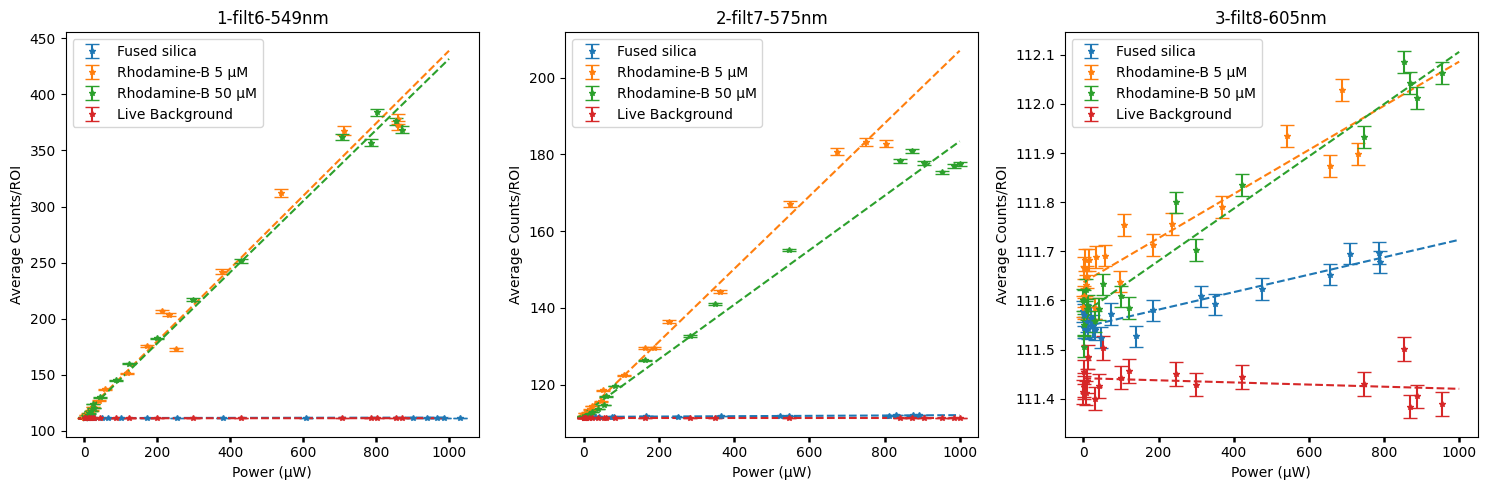

In [226]:
filters = ['1-filt6-549nm', '2-filt7-575nm', '3-filt8-605nm']
sample_names = ['Fused silica', 'Rhodamine-B 5 µM', 'Rhodamine-B 50 µM', 'Live Background']
fig, ax = plt.subplots(1, 3, figsize=(15, 5))
for i, f in enumerate(filters):
    for j, sample in enumerate([fs, rhb5, rhb50, bg50]):
        power_df = sample[f]
        linear_fit = np.poly1d(np.polyfit(power_df['power(uW)'], power_df['avg_counts'], 1))
        x_fit = np.linspace(0, 1000, 100)
        
        lines = ax[i].errorbar(power_df['power(uW)'], power_df['avg_counts'], yerr=power_df['std_counts'], fmt='*', label=sample_names[j])
        ax[i].plot(x_fit, linear_fit(x_fit), '--', color = lines[0].get_color())

    ax[i].set(xlabel='Power (µW)', ylabel='Average Counts/ROI', xscale='linear', title=f)
    ax[i].legend()
fig.tight_layout()

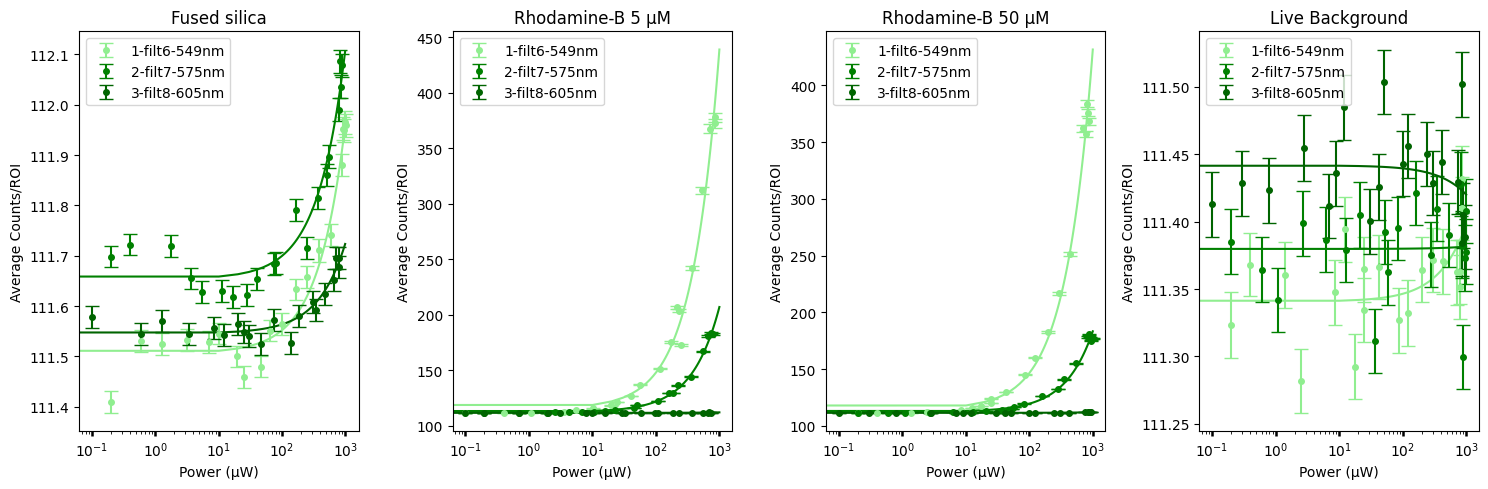

In [196]:
filters = ['1-filt6-549nm', '2-filt7-575nm', '3-filt8-605nm']
sample_names = ['Fused silica', 'Rhodamine-B 5 µM', 'Rhodamine-B 50 µM', 'Live Background']
colors = ['lightgreen', 'g', 'darkgreen']

fig, ax = plt.subplots(1, 4, figsize=(15, 5))
for i, sample in enumerate([fs, rhb5, rhb50, bg50]):
    for j, f in enumerate(filters):
        power_df = sample[f]
        linear_fit = np.poly1d(np.polyfit(power_df['power(uW)'], power_df['avg_counts'], 1))
        x_fit = np.linspace(0, 1000, 100)
        
        lines = ax[i].errorbar(power_df['power(uW)'], power_df['avg_counts'], yerr=power_df['std_counts'], fmt='o', color=colors[j], label=f)
        ax[i].plot(x_fit, linear_fit(x_fit), '-', color = lines[0].get_color())

    ax[i].set(xlabel='Power (µW)', ylabel='Average Counts/ROI', xscale='log', title=sample_names[i])
    ax[i].legend()
fig.tight_layout()

# Compute spectra

In [ ]:
def process_counts(arr_counts, filter_df, power):
    """Process the counts from the images."""
    arr_counts = np.array(arr_counts).ravel()
    arr_counts /= filter_df.mean_qe[:10]
    arr_counts /= power   # Divide by the QE and the power
    arr_counts /= (filter_df.range_width[:10]*2)  # Divide by the uncertainty in the transmission
    return arr_counts

In [50]:
def add_roi_info(filter_df, roi, imroi_size):
    """Add ROI information to the filter DataFrame."""
    filter_df.loc['roi_x', 'central_lambda'] = roi[0] + (roi[1] - roi[0]) / 2
    filter_df.loc['roi_y', 'central_lambda'] = roi[2] + (roi[3] - roi[2]) / 2
    filter_df.loc['roi_x', 'range_width'] = roi[1] - roi[0]
    filter_df.loc['roi_y', 'range_width'] = roi[3] - roi[2]
    filter_df.loc['roi_x', 'range_low'] = roi[0]
    filter_df.loc['roi_y', 'range_low'] = roi[2]
    filter_df.loc['roi_x', 'range_high'] = roi[1]
    filter_df.loc['roi_y', 'range_high'] = roi[3]
    filter_df.loc['roi_x', 'sum_counts'] = imroi_size
    filter_df.loc['roi_y', 'sum_counts'] = imroi_size
    return filter_df

In [51]:
def get_spectra(path, roi):
    """Plot the power ramp data for the specified path."""
    files = sorted(glob(path + '\*.tif'))
    power = get_power(path)
    nfilt = len(files)

    for f in files:
        if 'Center-NA' in f:
            f0 = f
        elif 'Dark_Blind' in f:
            fdark = f
    img0 = io.imread(f0).astype(np.int64)
    img_dark = io.imread(fdark).astype(np.int64)
    img_dark = img_dark[roi[0]:roi[1], roi[2]:roi[3]]
    # name = os.path.split(f0)[-1]

    filtstats_path = r'G:\My Drive\Ba Tagging\code\imag_analisis\filter_stats.csv'
    filter_df = pd.read_csv(filtstats_path, index_col=0)

    avg_counts = []
    std_counts = []
    sum_counts = []
    for i in range(nfilt - 2):
        img0 = io.imread(files[i]).astype(np.int64)

        imroi = img0[roi[0]:roi[1], roi[2]:roi[3]]
        imroi -= img_dark
        avg_counts.append(imroi.mean())
        sum_counts.append(imroi.sum())
        std_counts.append(imroi.std() / np.sqrt(imroi.size))

    avg_counts = process_counts(avg_counts, filter_df, power)
    std_counts = process_counts(std_counts, filter_df, power)
    sum_counts = process_counts(sum_counts, filter_df, power)

    filter_df['avg_counts'] = avg_counts
    filter_df['std_counts'] = std_counts
    filter_df['sum_counts'] = sum_counts
    # filter_df['power(uW)'] = power

    filter_df = add_roi_info(filter_df, roi, imroi.size)

    return filter_df    

In [67]:
def plot_spectra(df, name = None, ax = None):
    """Plot the spectra for the specified paths."""

    ax.errorbar(df['central_lambda'], df['avg_counts'], xerr=df['range_width'], yerr=df['std_counts'], fmt='-o', label=name)
    ax.set(xlabel='Wavelength (nm)', ylabel='Counts/ROI/nm/$\mu$W',)
    ax.legend()
    

In [54]:
pathrb50 = r'G:\My Drive\Ba Tagging\data\img\sets\03-04-25\Rhodamine-B 50 µM 270225\1'
pathrb5 = r'G:\My Drive\Ba Tagging\data\img\sets\03-04-25\Rhodamine-B 5 µM 270225\1'
pathfs = r'G:\My Drive\Ba Tagging\data\img\sets\03-04-25\quartz\1'
df50 = get_spectra(pathrb50, roi=roi)
df5 = get_spectra(pathrb5, roi=roi)
dffs = get_spectra(pathfs, roi=roi)

P = 0.0257 µW
P = 0.0147 µW
P = 0.0221 µW


In [78]:
path_ref = r'G:\My Drive\Ba Tagging\spectra\reference_spectra\Rhodamine_B.csv'
rhb_ref = pd.read_csv(path_ref, names=['Wavelength', 'intensity'], skiprows=1, index_col=0)
rhb_ref['intensity'] = rhb_ref['intensity'] * df50['avg_counts'].max()

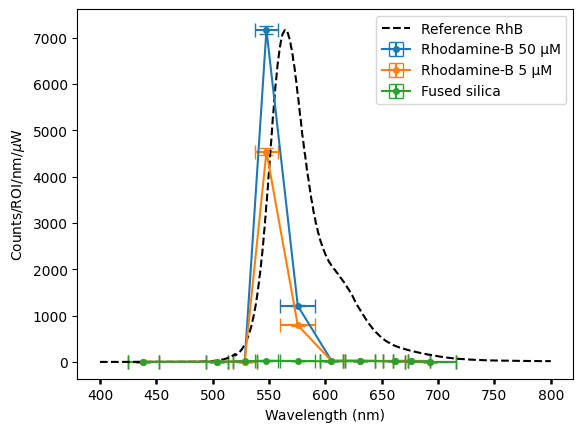

In [84]:
names = ['Rhodamine-B 50 µM', 'Rhodamine-B 5 µM', 'Fused silica']
for i, df in enumerate([df50, df5, dffs]):
    plot_spectra(df, name = names[i], ax = plt.gca())
plt.plot(rhb_ref['intensity'], color='k', ls='--', label = 'Reference RhB')
plt.legend()
fig.tight_layout()

# Analyse spectra at different focal points

In [132]:
from mpl_toolkits.mplot3d import Axes3D

In [145]:
def get_zpos(path):
    """Get the z position from the settings file.
    Args: path: string with the path to the directory with the settings file.
    Returns: zpos: float with the exposure time.
    """
    file_settings = path + '/settings.json'
    df_settings = pd.read_csv(file_settings, sep=':', names=['setting', 'value'], index_col='setting')
    power = float(df_settings.loc['ZPOS(mm)'].values[0])
    return power

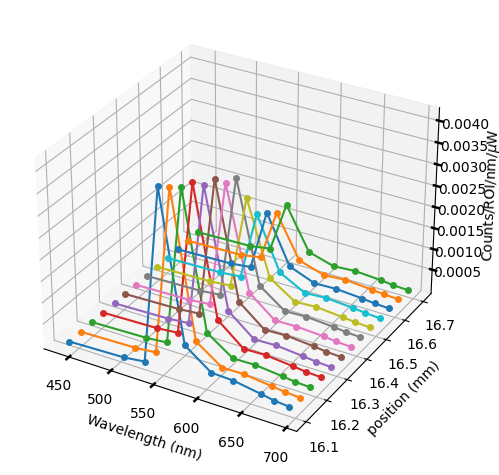

In [205]:
path0 = r'G:\My Drive\Ba Tagging\data\img\sets\06-04-25\Rhodamine-B 50 µM 270225'
subdirs = [x[0] for x in os.walk(path0)][1:]
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
zpos = []
spectra = np.zeros((len(subdirs), 10))
df['central_lambda']
for i, s in enumerate(subdirs):
    path = os.path.join(path0, s)
    zpos.append(get_zpos(path))
    
    df = pd.read_csv(path + '\spectrum_data.csv')
    counts = df['avg_counts'].dropna().values
    spectra[i] = counts[:10]

lamdas = df['central_lambda'].values[:10]
for z, sp in zip(zpos, spectra):
    Z = np.full_like(lamdas, z)
    ax.plot(lamdas, Z, sp, '-o', )

ax.set(xlabel='Wavelength (nm)', ylabel='position (mm)', zlabel='Counts/ROI/nm/$\mu$W')
fig.tight_layout()
# ax.legend()

In [193]:
len(subdirs)

13

In [200]:
zpos

[16.1,
 16.15,
 16.2,
 16.25,
 16.3,
 16.35,
 16.4,
 16.45,
 16.5,
 16.55,
 16.6,
 16.65,
 16.7]

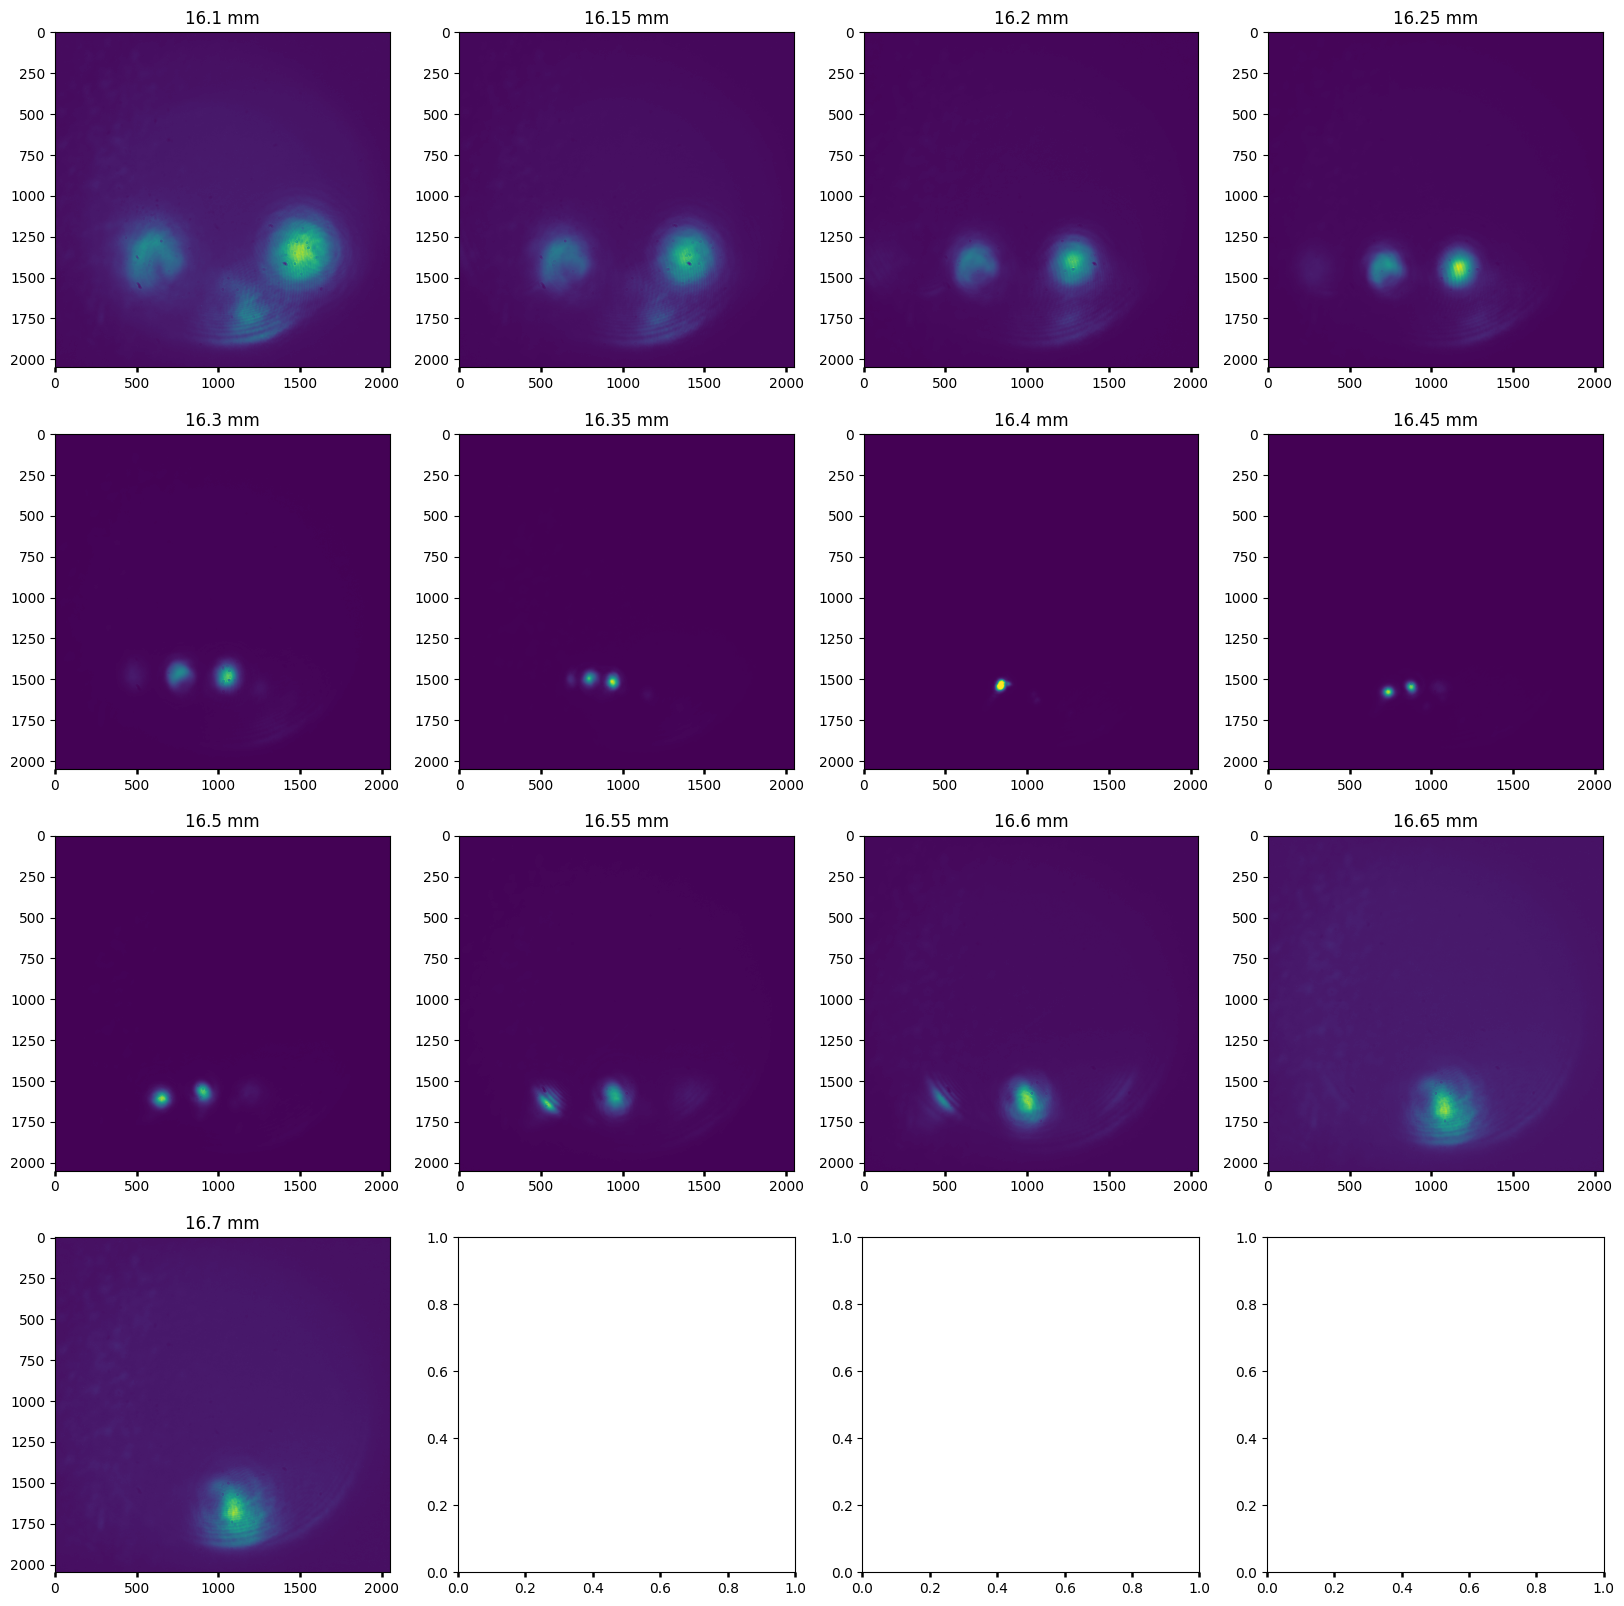

In [204]:
path0 = r'G:\My Drive\Ba Tagging\data\img\sets\06-04-25\Rhodamine-B 50 µM 270225'
subdirs = [x[0] for x in os.walk(path0)][1:]
fig, ax = plt.subplots(4, 4, figsize=(20, 20))
for i, s in enumerate(subdirs):
    j, k = divmod(i, 4)
    path = os.path.join(path0, s)
    files = sorted(glob(path + '\*.tif'))
    for f in files:
        if 'Center-NA' in f:
            f0 = f
        
    img0 = io.imread(f0).astype(np.int64)
    ob = ax[j, k].imshow(img0)
    ax[j, k].set_title(str(zpos[i]) + ' mm')


# Check photobleaching in spectrum across the filters

In [242]:
pathrb50b = r'G:\My Drive\Ba Tagging\data\img\sets\08-04-25\Rhodamine-B 50 µM 270225'
subdirs = [x[0] for x in os.walk(pathrb50b)][1:]
df_res = pd.DataFrame()

for n, s in enumerate(subdirs):
    df_filter = pd.read_csv(s+'\spectrum_data.csv', index_col=0)
    df_filter = df_filter['avg_counts'].dropna().T
    df_res = pd.concat([df_res, df_filter], axis=1)
    
df_res.columns = [s.split('\\')[-1] for s in subdirs]
df_res = df_res.T

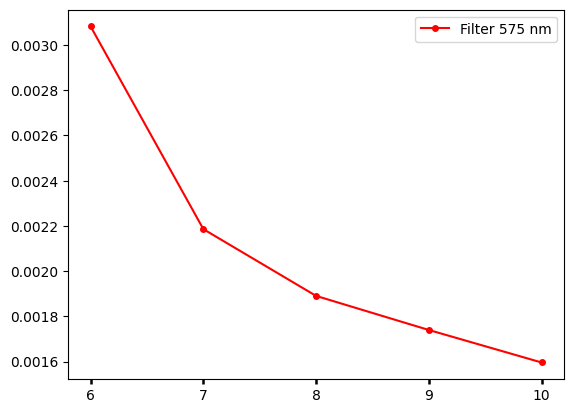

In [294]:
plt.plot(df_res['filter07_575nm'][:-1], 'ro-', label='Filter 575 nm')
plt.legend()

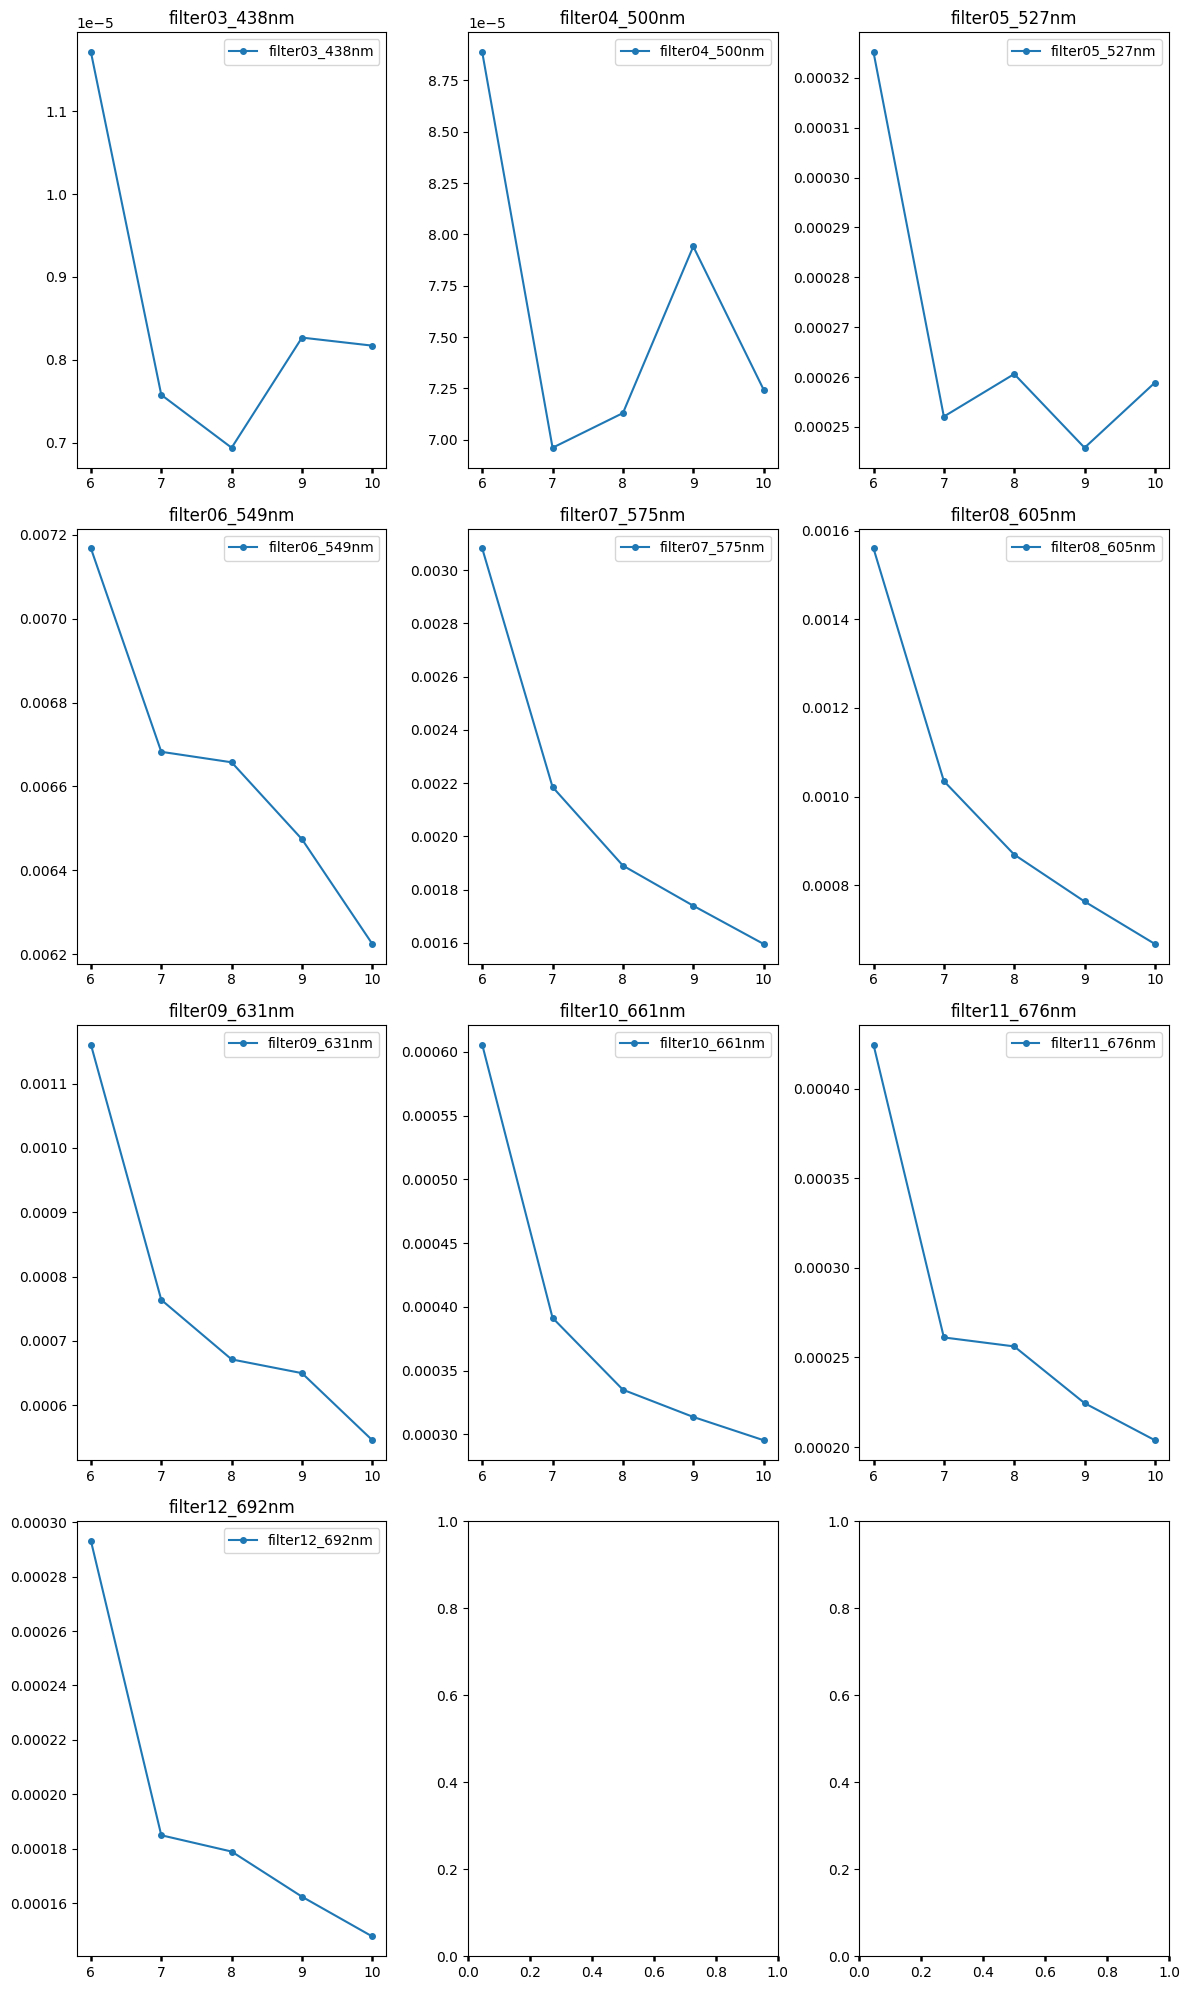

In [305]:
fig, ax = plt.subplots(4, 3, figsize=(12, 20))
for i, col in enumerate(df_res.columns):
    j, k = divmod(i, 3)
    ax[j, k].plot(df_res[col][:-1], 'o-', label=col)
    ax[j, k].set_title(col)
    ax[j, k].legend()
plt.tight_layout()

In [306]:
7*12

84

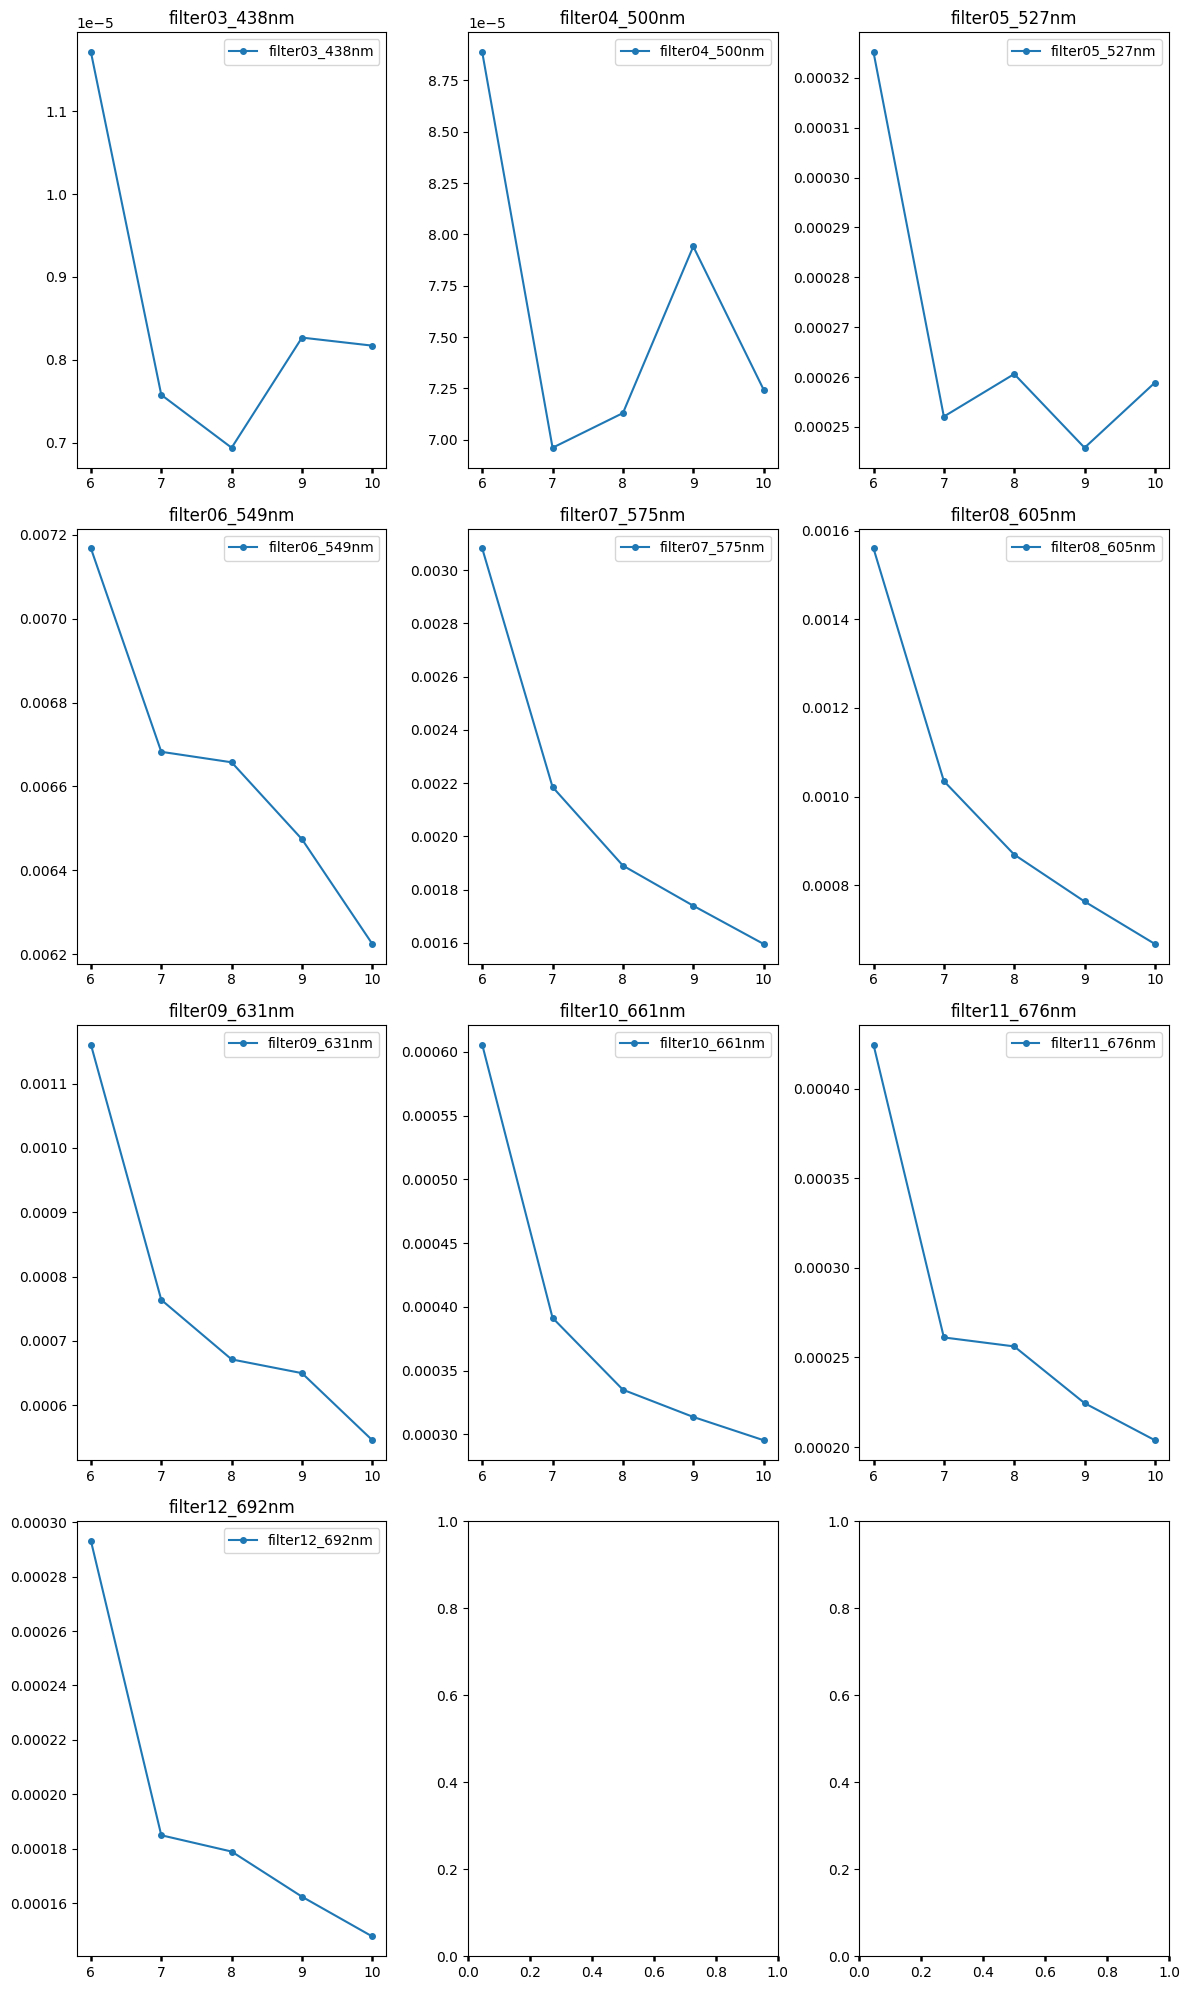

In [308]:
fig, ax = plt.subplots(4, 3, figsize=(12, 20))
x = np.linspace(0, 7*12*len(df_res.columns), len(df_res.columns))
for i, col in enumerate(df_res.columns):
    j, k = divmod(i, 3)
    ax[j, k].plot(df_res[col][:-1], 'o-', label=col)
    ax[j, k].set_title(col)
    ax[j, k].legend()
plt.tight_layout()

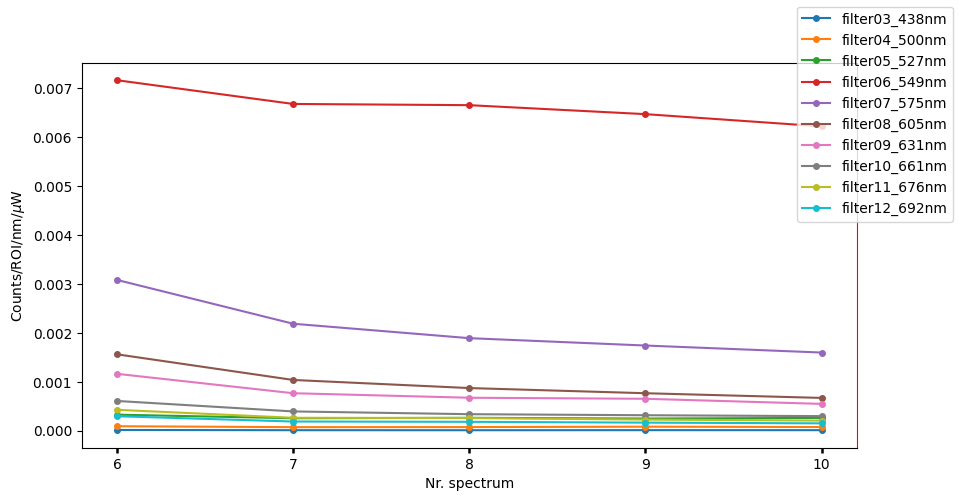

In [291]:
fig = plt.figure(figsize=(10, 5))
ax = fig.add_subplot(111)
# ax2 = ax.twinx()
for col in df_res.columns:
    # if col != 'filter07_575nm':
    ax.plot(df_res[col][:-1], 'o-', label=col)
    # else:
        # ax2.plot(df_res[col][:-1], 'ko-', label=col)
ax.spines['right'].set_color('red')
# ax2.tick_params(axis='y', colors='red')
# ax2.set(ylabel='Counts/ROI/nm/$\mu$W',)
ax.set(xlabel='Nr. spectrum', ylabel='Counts/ROI/nm/$\mu$W')
fig.legend()